In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import numpy as np

In [25]:
algos = ['simclr', 'vicreg']
algo = algos[0]

In [26]:
CSV_SAMPLES = f"/home/luthra/directional_cdnv_bounds/multi_labelings/results/{algo}/all_pair_cos.csv"
df_samples = pd.read_csv(CSV_SAMPLES)
# create combo string
df_samples["combo"] = (
    df_samples["label_key1"].str.capitalize()
    + " vs. "
    + df_samples["label_key2"].str.capitalize()
)
EPOCHS = np.unique(df_samples['epoch'].values)
# print(df_samples.head())

METRICS_FILE = f"/home/luthra/directional_cdnv_bounds/multi_labelings/results/{algo}/all_pair_metrics.csv"
df_metrics = pd.read_csv(METRICS_FILE)

### Double panel

In [ ]:
def set_border(ax):
    for spine in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(1)


def plot_all_avg_bounds(
    df_samples: pd.DataFrame,
    df_metrics: pd.DataFrame,
    out_path: str = "all_avg_bounds.pdf",
    eps: float = 1e-12,
    alpha: float = 0.18,
):

    sns.set_theme(style="whitegrid", font_scale=2.0)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
    ax_left, ax_right = axes

    set_border(ax_left)
    set_border(ax_right)

    # -----------------------------
    # Helper to compute stats
    # -----------------------------
    def compute_stats(label1, label2):

        # 1. Filter for the relevant pairs, capturing both orderings
        mask_forward = (df_samples["label_key1"] == label1) & (df_samples["label_key2"] == label2)
        mask_backward = (df_samples["label_key1"] == label2) & (df_samples["label_key2"] == label1)
        
        df = df_samples[mask_forward | mask_backward].copy()

        if df.empty:
            return None

        epochs = np.array(sorted(df["epoch"].unique()))

        # 2. Merge metrics for the FIRST key in the sample
        df_tmp = df.merge(
            df_metrics,
            left_on=["epoch", "label_key1", "key1_class1", "key1_class2"],
            right_on=["epoch", "label_key", "class1", "class2"],
            how="left"
        ).rename(columns={"d": "d1", "K": "K1", "V": "V1"}).drop(columns=["label_key", "class1", "class2"])

        # 3. Merge metrics for the SECOND key in the sample
        df_tmp = df_tmp.merge(
            df_metrics,
            left_on=["epoch", "label_key2", "key2_class1", "key2_class2"],
            right_on=["epoch", "label_key", "class1", "class2"],
            how="left"
        ).rename(columns={"d": "d2", "K": "K2", "V": "V2"}).drop(columns=["label_key", "class1", "class2"])

        # 4. Extract arrays for vectorized math
        d1 = df_tmp["d1"].to_numpy()
        d2 = df_tmp["d2"].to_numpy()
        K1 = df_tmp["K1"].to_numpy()
        K2 = df_tmp["K2"].to_numpy()
        V1 = df_tmp["V1"].to_numpy()
        V2 = df_tmp["V2"].to_numpy()

        # 5. Compute the theoretical bound strictly adhering to Proposition 4.2
        term1 = (d1 / d2) * np.sqrt(2 * K2 * V1)
        term2 = (d2 / d1) * np.sqrt(2 * K1 * V2)

        pair_bound = np.minimum(term1, term2)
        pair_bound = np.clip(pair_bound, eps, None)
        df_tmp["pair_bound"] = pair_bound

        # 6. Calculate LHS stats (empirical cosine similarity)
        lhs_stats = (
            df_tmp.groupby("epoch")["mod_cos_sim"]
            .quantile([0.25, 0.50, 0.75])
            .unstack()
            .reindex(epochs)
            .rename(columns={0.25: "q25", 0.50: "median", 0.75: "q75"})
        )

        # 7. Calculate RHS stats (theoretical bound: mean + quantiles)
        rhs_stats = (
            df_tmp.groupby("epoch")["pair_bound"]
            .quantile([0.25, 0.50, 0.75])
            .unstack()
            .reindex(epochs)
            .rename(columns={0.25: "q25", 0.50: "median", 0.75: "q75"})
        )
        # Keep the mean as the primary dashed line, as requested originally
        rhs_stats["mean"] = df_tmp.groupby("epoch")["pair_bound"].mean().reindex(epochs)

        return epochs, lhs_stats, rhs_stats

    # -----------------------------
    # Panel A: Color vs *
    # -----------------------------
    color_pairs = ["shape", "size_label", "style"]
    palette_left = sns.color_palette("Set1", n_colors=len(color_pairs))

    for label2, color in zip(color_pairs, palette_left):

        result = compute_stats("color", label2)
        if result is None:
            continue

        epochs, lhs_stats, rhs_stats = result
        x = epochs + 1

        # Empirical similarity
        med_lhs = np.clip(lhs_stats["median"].to_numpy(), eps, None)
        lo_lhs  = np.clip(lhs_stats["q25"].to_numpy(), eps, None)
        hi_lhs  = np.clip(lhs_stats["q75"].to_numpy(), eps, None)

        ax_left.plot(x, med_lhs, color=color, linewidth=2.5,
                     label=f"Color vs. {label2.replace('_label','').capitalize()}")
        ax_left.fill_between(x, lo_lhs, hi_lhs, alpha=alpha, color=color)

        # Theoretical bound
        mean_rhs = np.clip(rhs_stats["median"].to_numpy(), eps, None)
        lo_rhs   = np.clip(rhs_stats["q25"].to_numpy(), eps, None)
        hi_rhs   = np.clip(rhs_stats["q75"].to_numpy(), eps, None)

        ax_left.plot(x, mean_rhs, linestyle="--", linewidth=2.5, color=color)
        ax_left.fill_between(x, lo_rhs, hi_rhs, alpha=alpha*0.4, color=color, linestyle="--")

    ax_left.set_xlabel("Epoch")
    ax_left.set_ylabel("Cosine Similarity")
    ax_left.set_yscale("log", base=2)
    ax_left.set_ylim(bottom=2**-7, top=2**3)
    ax_left.legend(frameon=True, loc='upper right')
    tick_locs = [2**i for i in range(-6, 3)]
    tick_labels = [f"$2^{{{i}}}$" for i in range(-6, 3)]
    
    ax_left.set_yticks(tick_locs)
    ax_left.set_yticklabels(tick_labels)

    # -----------------------------
    # Panel B: Remaining pairs
    # -----------------------------
    other_pairs = [
        ("shape", "size_label"),
        ("shape", "style"),
        ("size_label", "style")
    ]
    palette_right = sns.color_palette("Set2", n_colors=len(other_pairs))

    for (label1, label2), color in zip(other_pairs, palette_right):

        result = compute_stats(label1, label2)
        if result is None:
            continue

        epochs, lhs_stats, rhs_stats = result
        x = epochs + 1

        name1 = label1.replace("_label", "").capitalize()
        name2 = label2.replace("_label", "").capitalize()

        # Empirical similarity
        med_lhs = np.clip(lhs_stats["median"].to_numpy(), eps, None)
        lo_lhs  = np.clip(lhs_stats["q25"].to_numpy(), eps, None)
        hi_lhs  = np.clip(lhs_stats["q75"].to_numpy(), eps, None)

        ax_right.plot(x, med_lhs, color=color, linewidth=2.5,
                      label=f"{name1} vs. {name2}")
        ax_right.fill_between(x, lo_lhs, hi_lhs, alpha=alpha, color=color)

        # Theoretical bound
        mean_rhs = np.clip(rhs_stats["median"].to_numpy(), eps, None)
        lo_rhs   = np.clip(rhs_stats["q25"].to_numpy(), eps, None)
        hi_rhs   = np.clip(rhs_stats["q75"].to_numpy(), eps, None)

        ax_right.plot(x, mean_rhs, linestyle="--", linewidth=2.5, color=color)
        ax_right.fill_between(x, lo_rhs, hi_rhs, alpha=alpha*0.4, color=color, linestyle="--")

    ax_right.set_xlabel("Epoch")
    # ax_right.set_yscale("log", base=2)
    ax_right.legend(frameon=True, loc='upper right')

    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=200)
    plt.show()

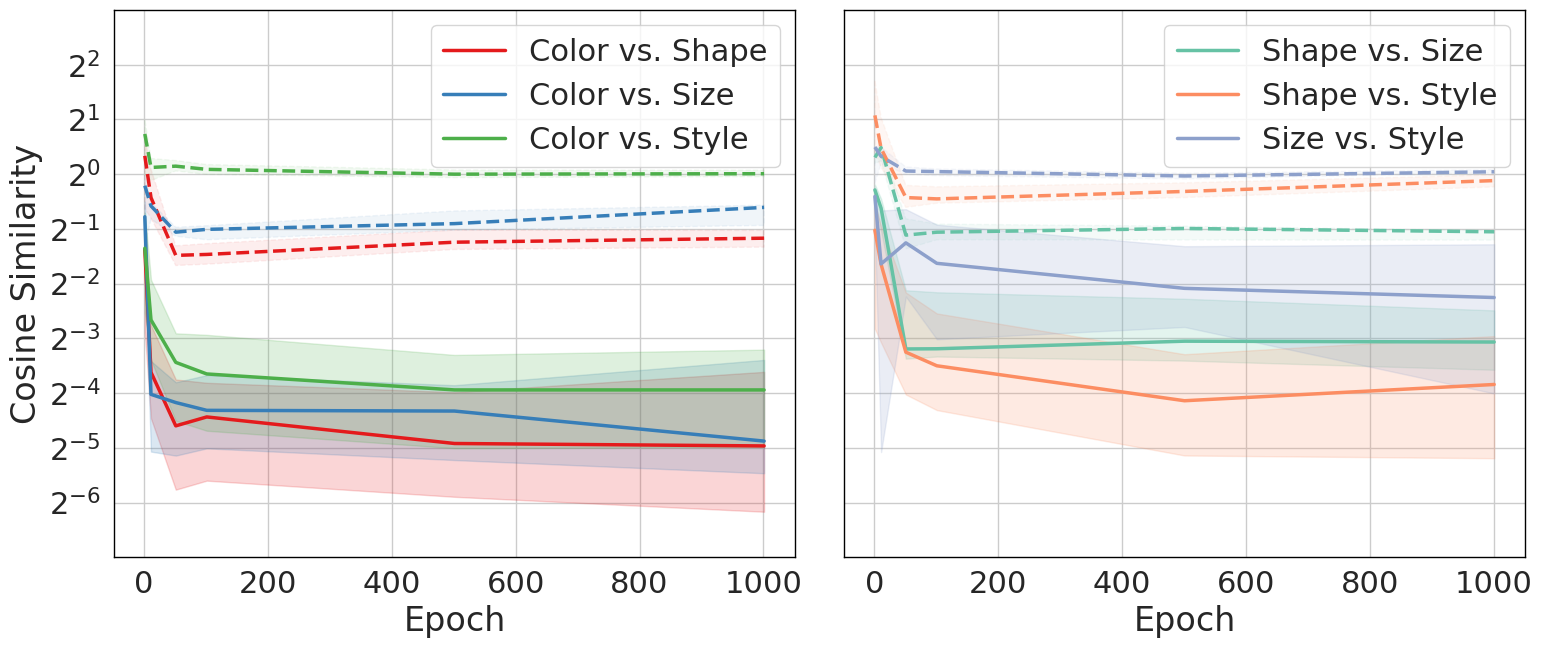

In [9]:
plot_all_avg_bounds(
    df_samples,
    df_metrics,
    out_path=None
)

### Single Panel

In [27]:
def set_border(ax):
    for spine in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(1)


def plot_sel_avg_bounds(
    df_samples: pd.DataFrame,
    df_metrics: pd.DataFrame,
    out_path: str = "all_avg_bounds.pdf",
    eps: float = 1e-12,
    alpha: float = 0.18,
):

    sns.set_theme(style="whitegrid", font_scale=2.0)

    fig, ax = plt.subplots(1, 1, figsize=(9, 8))
    set_border(ax)

    # -----------------------------
    # Helper to compute stats
    # -----------------------------
    def compute_stats(label1, label2):

        # 1. Filter for the relevant pairs, capturing both orderings
        mask_forward = (df_samples["label_key1"] == label1) & (df_samples["label_key2"] == label2)
        mask_backward = (df_samples["label_key1"] == label2) & (df_samples["label_key2"] == label1)
        
        df = df_samples[mask_forward | mask_backward].copy()

        if df.empty:
            return None

        epochs = np.array(sorted(df["epoch"].unique()))

        # 2. Merge metrics for the FIRST key in the sample
        df_tmp = df.merge(
            df_metrics,
            left_on=["epoch", "label_key1", "key1_class1", "key1_class2"],
            right_on=["epoch", "label_key", "class1", "class2"],
            how="left"
        ).rename(columns={"d": "d1", "K": "K1", "V": "V1"}).drop(columns=["label_key", "class1", "class2"])

        # 3. Merge metrics for the SECOND key in the sample
        df_tmp = df_tmp.merge(
            df_metrics,
            left_on=["epoch", "label_key2", "key2_class1", "key2_class2"],
            right_on=["epoch", "label_key", "class1", "class2"],
            how="left"
        ).rename(columns={"d": "d2", "K": "K2", "V": "V2"}).drop(columns=["label_key", "class1", "class2"])

        # 4. Extract arrays for vectorized math
        d1 = df_tmp["d1"].to_numpy()
        d2 = df_tmp["d2"].to_numpy()
        K1 = df_tmp["K1"].to_numpy()
        K2 = df_tmp["K2"].to_numpy()
        V1 = df_tmp["V1"].to_numpy()
        V2 = df_tmp["V2"].to_numpy()

        # 5. Compute the theoretical bound strictly adhering to Proposition 4.2
        term1 = (d1 / d2) * np.sqrt(2 * K2 * V1)
        term2 = (d2 / d1) * np.sqrt(2 * K1 * V2)

        pair_bound = np.minimum(term1, term2)
        pair_bound = np.clip(pair_bound, eps, None)
        df_tmp["pair_bound"] = pair_bound

        # 6. Calculate LHS stats (empirical cosine similarity)
        lhs_stats = (
            df_tmp.groupby("epoch")["mod_cos_sim"]
            .quantile([0.25, 0.50, 0.75])
            .unstack()
            .reindex(epochs)
            .rename(columns={0.25: "q25", 0.50: "median", 0.75: "q75"})
        )

        # 7. Calculate RHS stats (theoretical bound: mean + quantiles)
        rhs_stats = (
            df_tmp.groupby("epoch")["pair_bound"]
            .quantile([0.25, 0.50, 0.75])
            .unstack()
            .reindex(epochs)
            .rename(columns={0.25: "q25", 0.50: "median", 0.75: "q75"})
        )
        # Keep the mean as the primary dashed line, as requested originally
        rhs_stats["mean"] = df_tmp.groupby("epoch")["pair_bound"].mean().reindex(epochs)

        return epochs, lhs_stats, rhs_stats

    # -----------------------------
    # Panel A
    # -----------------------------
    sel_pairs = [
        ("color", "shape"),
        ("color", "size_label"),
        ("shape", "size_label")
    ]
    palette_left = sns.color_palette("Set1", n_colors=len(sel_pairs))

    for (label1, label2), color in zip(sel_pairs, palette_left):

        result = compute_stats(label1, label2)
        if result is None:
            continue

        epochs, lhs_stats, rhs_stats = result
        x = epochs + 1

        name1 = label1.replace("_label", "").capitalize()
        name2 = label2.replace("_label", "").capitalize()

        # Empirical similarity
        med_lhs = np.clip(lhs_stats["median"].to_numpy(), eps, None)
        lo_lhs  = np.clip(lhs_stats["q25"].to_numpy(), eps, None)
        hi_lhs  = np.clip(lhs_stats["q75"].to_numpy(), eps, None)

        ax.plot(x, med_lhs, color=color, linewidth=2.5,
                     label=f"{name1} vs. {name2}")
        ax.fill_between(x, lo_lhs, hi_lhs, alpha=alpha, color=color)

        # Theoretical bound
        mean_rhs = np.clip(rhs_stats["median"].to_numpy(), eps, None)
        lo_rhs   = np.clip(rhs_stats["q25"].to_numpy(), eps, None)
        hi_rhs   = np.clip(rhs_stats["q75"].to_numpy(), eps, None)

        ax.plot(x, mean_rhs, linestyle="--", linewidth=2.5, color=color)
        ax.fill_between(x, lo_rhs, hi_rhs, alpha=alpha*0.4, color=color, linestyle="--")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cosine Similarity")
    ax.set_yscale("log", base=2)
    ax.set_ylim(bottom=2**-7, top=2**3)
    tick_locs = [2**i for i in range(-6, 3)]
    tick_labels = [f"$2^{{{i}}}$" for i in range(-6, 3)]
    ax.set_yticks(tick_locs)
    ax.set_yticklabels(tick_labels)

    leg1 = ax.legend(frameon=True, loc='upper right')
    ax.add_artist(leg1)

    style_handles = [
        Line2D([0], [0], color='gray', linestyle='-', linewidth=2.5, label='Empirical'),
        Line2D([0], [0], color='gray', linestyle='--', linewidth=2.5, label='Our Bound')
    ]
    ax.legend(handles=style_handles, frameon=True,
              bbox_to_anchor=(0.5,1.0))

    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=200)
    plt.show()

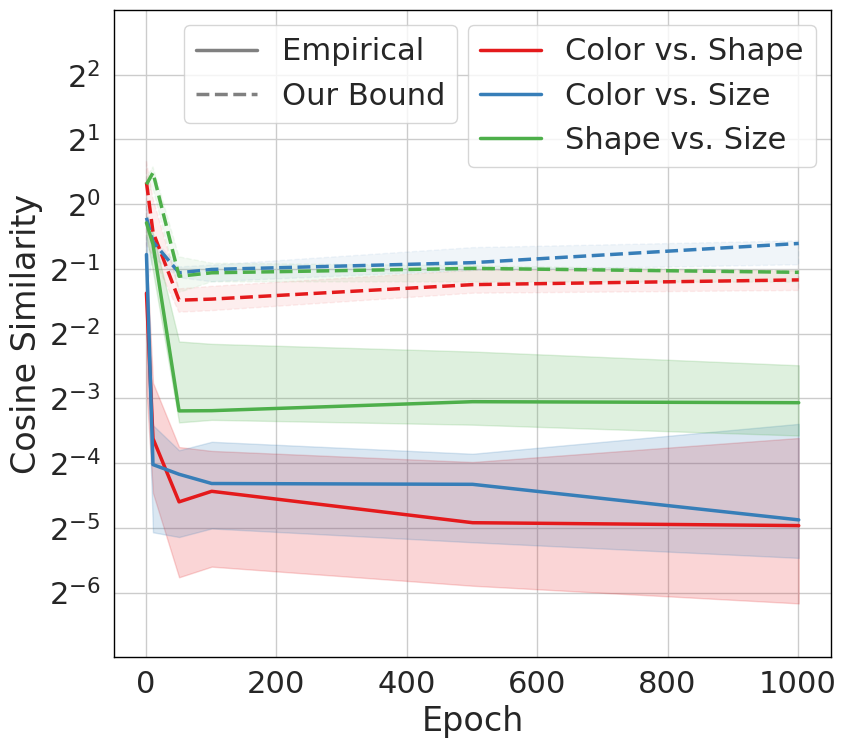

In [28]:
plot_sel_avg_bounds(
    df_samples,
    df_metrics,
    out_path=f"/home/luthra/directional_cdnv_bounds/multi_labelings/results/{algo}_orthogonality_bound.pdf"
)